In [1]:
!pip install ultralytics
!pip install opencv-python
!pip install matplotlib
!pip install streamlit

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [4]:
model = YOLO("yolov8n.pt")

print("Model Loaded Successfully")

Model Loaded Successfully



image 1/1 C:\Users\Aman\Aircraft_Detection\images\aircraft 4.jpg: 384x640 3 airplanes, 204.0ms
Speed: 9.3ms preprocess, 204.0ms inference, 15.5ms postprocess per image at shape (1, 3, 384, 640)


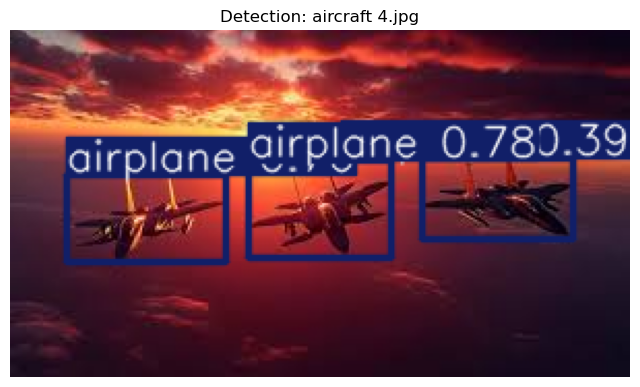


image 1/1 C:\Users\Aman\Aircraft_Detection\images\aircraft1.jpg: 448x640 3 airplanes, 216.4ms
Speed: 6.1ms preprocess, 216.4ms inference, 2.8ms postprocess per image at shape (1, 3, 448, 640)


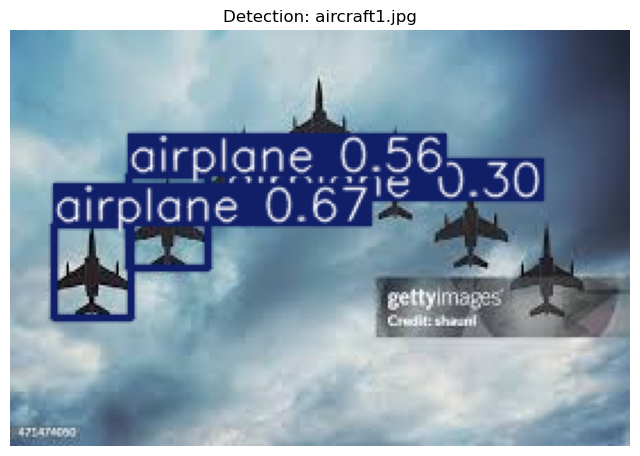


image 1/1 C:\Users\Aman\Aircraft_Detection\images\aircraft2.jpg: 384x640 1 bird, 152.5ms
Speed: 2.8ms preprocess, 152.5ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


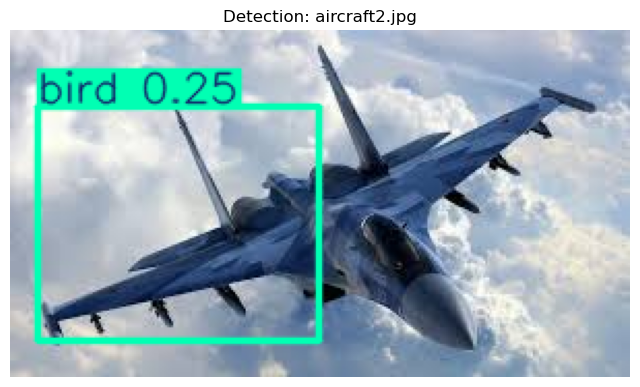


image 1/1 C:\Users\Aman\Aircraft_Detection\images\aircraft3.jpg: 640x512 1 airplane, 206.8ms
Speed: 6.3ms preprocess, 206.8ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 512)


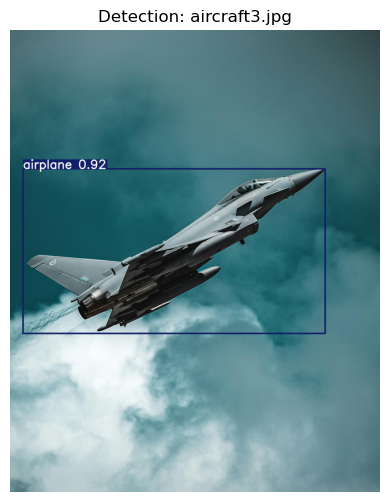


image 1/1 C:\Users\Aman\Aircraft_Detection\images\aircraft5.jpg: 640x448 1 person, 1 airplane, 1 bird, 194.2ms
Speed: 4.0ms preprocess, 194.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 448)


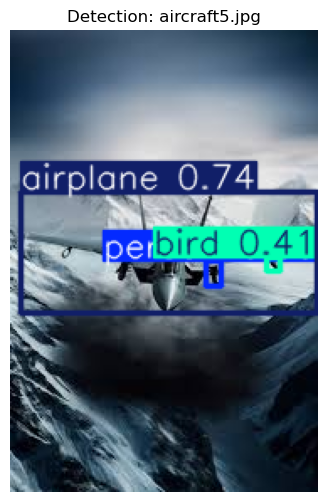

In [5]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

image_folder = "images"

for image_name in os.listdir(image_folder):

    image_path = os.path.join(image_folder, image_name)

    results = model(image_path)

    result_img = results[0].plot()

    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Detection: {image_name}")
    plt.axis("off")
    plt.show()

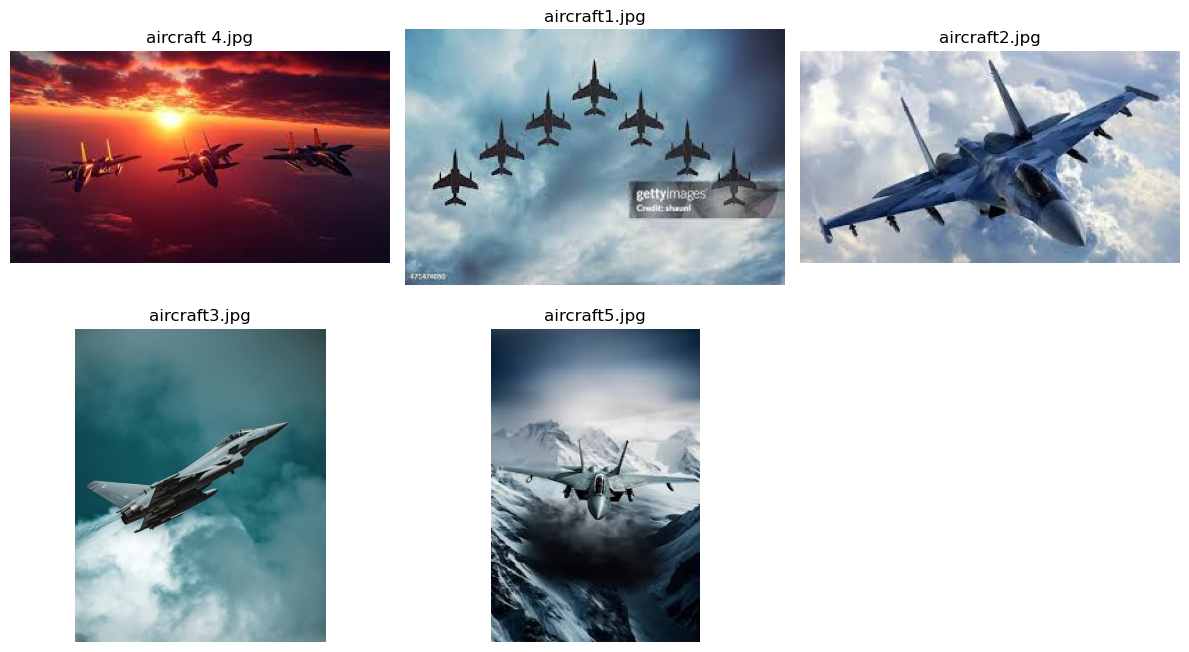

In [15]:
import os
import cv2
import matplotlib.pyplot as plt

folder = "images"

images = os.listdir(folder)

plt.figure(figsize=(12,10))

for i, image_name in enumerate(images[:9]):  # First 9 images

    path = os.path.join(folder, image_name)

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
results = model("images")

count = 0

for result in results:
    
    count += len(result.boxes)

print("Total Aircraft:", count)


image 1/5 C:\Users\Aman\Aircraft_Detection\images\aircraft 4.jpg: 384x640 3 airplanes, 208.9ms
image 2/5 C:\Users\Aman\Aircraft_Detection\images\aircraft1.jpg: 448x640 3 airplanes, 111.0ms
image 3/5 C:\Users\Aman\Aircraft_Detection\images\aircraft2.jpg: 384x640 1 bird, 185.3ms
image 4/5 C:\Users\Aman\Aircraft_Detection\images\aircraft3.jpg: 640x512 1 airplane, 240.2ms
image 5/5 C:\Users\Aman\Aircraft_Detection\images\aircraft5.jpg: 640x448 1 person, 1 airplane, 1 bird, 162.7ms
Speed: 4.6ms preprocess, 181.6ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 448)
Total Aircraft: 11


In [18]:
import os

image_folder = "images"

images = os.listdir(image_folder)

print("Total Images:", len(images))

Total Images: 5


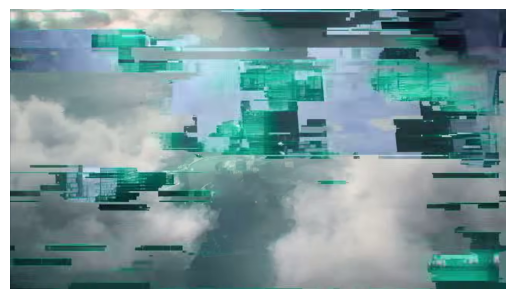

In [14]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import cv2

cap = cv2.VideoCapture("battlefield.mp4")

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)

    frame = results[0].plot()

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    clear_output(wait=True)

    plt.imshow(frame)
    plt.axis("off")
    plt.show()

cap.release()